# Plot of eddy distribution

#### Data Import

In [1]:
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import pandas as pd
import matplotlib.colors as colors
import time
from scipy.stats import linregress
import sys
print(sys.executable)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm


/home/b/b383696/.conda/envs/parcels_env/bin/python


In [2]:
#import data (generated in this notebook)
edso1_clt_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac.nc")
edso1_clt_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c.nc")

sh: getfattr: command not found
sh: getfattr: command not found


In [3]:
#import data
edso1_clt_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20.nc")

sh: getfattr: command not found


In [4]:
#import data
edso1_clt_ac_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_ac_q75_e20.nc")
edso1_clt_c_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_c_q75_e20.nc")

sh: getfattr: command not found
sh: getfattr: command not found


#### AC/C Distribution (all eddies)

In [4]:
lats_ac = edso1_clt_ac["latitude"].values.ravel()
lons_ac = edso1_clt_ac["longitude"].values.ravel()

lats_c = edso1_clt_c["latitude"].values.ravel()
lons_c = edso1_clt_c["longitude"].values.ravel()

#remove missing values
mask_ac = np.isfinite(lats_ac) & np.isfinite(lons_ac)
lats_ac = lats_ac[mask_ac]
lons_ac = lons_ac[mask_ac]

mask_c = np.isfinite(lats_c) & np.isfinite(lons_c)
lats_c = lats_c[mask_c]
lons_c = lons_c[mask_c]

In [5]:
proj = ccrs.SouthPolarStereo()
data_crs = ccrs.PlateCarree()

In [6]:
# Convert lon/lat to projection coordinates
xy_ac = proj.transform_points(data_crs, lons_ac, lats_ac)
x_ac = xy_ac[:, 0]
y_ac = xy_ac[:, 1]

xy_c = proj.transform_points(data_crs, lons_c, lats_c)
x_c = xy_c[:, 0]
y_c = xy_c[:, 1]

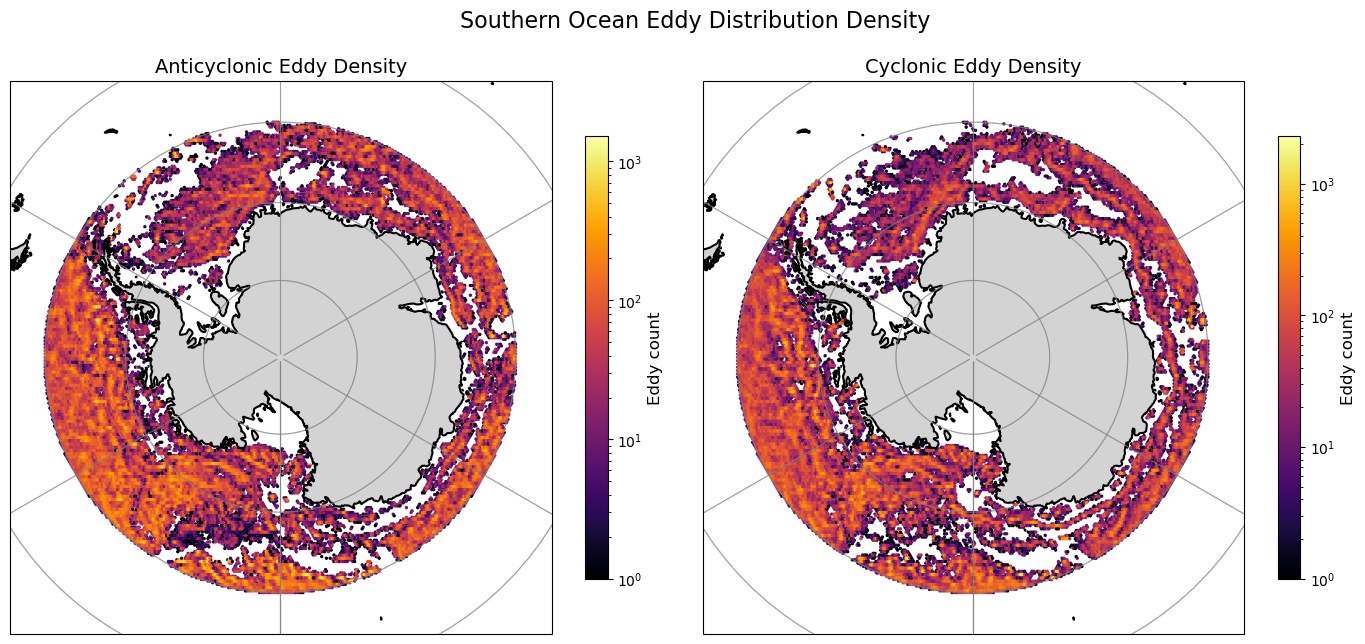

In [22]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 7),
    subplot_kw={"projection": proj}
)
ax1 = axes[0]
ax2 = axes[1]

# --- First subplot: Antcyclonic eddies ---
ax1 = axes[0]
ax1.set_extent([0,360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb1 = ax1.hexbin(
    x_ac, y_ac,                 # AC eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj
)

ax1.add_feature(cfeature.LAND, facecolor="lightgrey")
ax1.coastlines(linewidth=1.5)
cb1 = plt.colorbar(hb1, ax=ax1, shrink=0.7)
cb1.set_label("Eddy count", fontsize = 12)
ax1.set_title("Anticyclonic Eddy Density", fontsize = 14)

# --- Second subplot: Cyclonic eddies ---
ax2 = axes[1]
ax2.set_extent([0,360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb2 = ax2.hexbin(
    x_c, y_c,                   # Cyclonic eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj
)

ax2.add_feature(cfeature.LAND, facecolor="lightgrey")
ax2.coastlines(linewidth=1.5)
cb2 = plt.colorbar(hb2, ax=ax2, shrink=0.7)
cb2.set_label("Eddy count", fontsize = 12)
ax2.set_title("Cyclonic Eddy Density", fontsize = 14)

fig.suptitle("Southern Ocean Eddy Distribution Density", fontsize=16, y=0.97)

plt.tight_layout()
plt.savefig("eddy_distribution_density.pdf")
plt.show()


In [11]:
lats_ac = edso2_clt_ac["latitude"].values.ravel()
lons_ac = edso2_clt_ac["longitude"].values.ravel()

lats_c = edso2_clt_c["latitude"].values.ravel()
lons_c = edso2_clt_c["longitude"].values.ravel()


In [12]:
lats_ac

array([-75.79973 , -75.7805  , -75.798225, ..., -69.080605, -69.061134,
       -69.03491 ], shape=(1958115,), dtype=float32)

In [13]:
lons_ac

array([203.84216 , 203.68143 , 203.54549 , ...,  13.558386,  13.451894,
        13.298314], shape=(1958115,), dtype=float32)

In [14]:
#remove missing values
mask_ac = np.isfinite(lats_ac) & np.isfinite(lons_ac)
lats_ac = lats_ac[mask_ac]
lons_ac = lons_ac[mask_ac]

mask_c = np.isfinite(lats_c) & np.isfinite(lons_c)
lats_c = lats_c[mask_c]
lons_c = lons_c[mask_c]

In [15]:
#define project
proj_ac = ccrs.SouthPolarStereo()
data_crs_ac = ccrs.PlateCarree()

proj_c = ccrs.SouthPolarStereo()
data_crs_c = ccrs.PlateCarree()

In [16]:
# Convert lon/lat to projection coordinates
xy_ac = proj_ac.transform_points(data_crs_ac, lons_ac, lats_ac)
x_ac = xy_ac[:, 0]
y_ac = xy_ac[:, 1]

xy_c = proj_c.transform_points(data_crs_c, lons_c, lats_c)
x_c = xy_c[:, 0]
y_c = xy_c[:, 1]

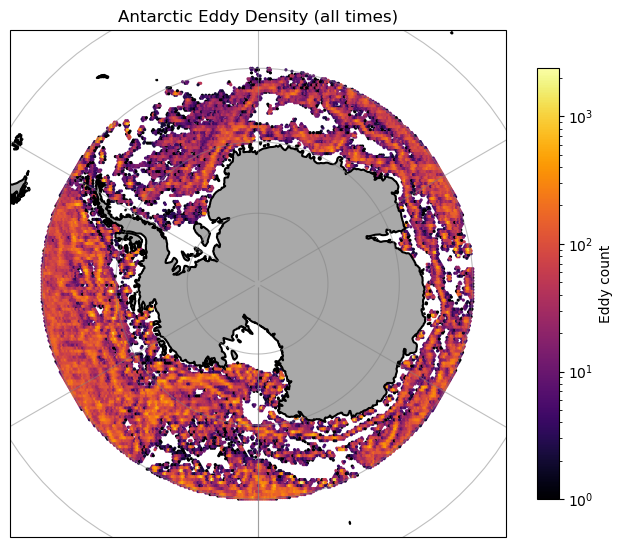

In [21]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj_c)

ax.set_extent([0,360, -90, -55], crs=ccrs.PlateCarree())

gl = ax.gridlines(
    draw_labels=False,
    linewidth=0.8,
    color="grey",
    alpha=0.5,
    linestyle="-"
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}


hb = ax.hexbin(
    x_c, y_c,
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj_c
)

ax.add_feature(cfeature.LAND, facecolor="darkgrey")
ax.coastlines(linewidth=1.5)

cb = plt.colorbar(hb, ax=ax, shrink=0.7)
cb.set_label("Eddy count")

ax.set_title("Antarctic Eddy Density (all times)")
plt.show()


In [5]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 7),
    subplot_kw={"projection": proj_c}
)
ax1 = axes[0]
ax2 = axes[1]

# --- First subplot: AC eddies ---
ax1 = axes[0]
ax1.set_extent([0, 360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb1 = ax1.hexbin(
    x_ac, y_ac,                 # AC eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj_c
)

ax1.add_feature(cfeature.LAND, facecolor="darkgrey")
ax1.coastlines(linewidth=1.5)
cb1 = plt.colorbar(hb1, ax=ax1, shrink=0.7)
cb1.set_label("Eddy count")
ax1.set_title("Anticyclonic Eddy Density")

# --- Second subplot: C eddies ---
ax2 = axes[1]
ax2.set_extent([0, 360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb2 = ax2.hexbin(
    x_c, y_c,                   # Cyclonic eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj_c
)

ax2.add_feature(cfeature.LAND, facecolor="darkgrey")
ax2.coastlines(linewidth=1.5)
cb2 = plt.colorbar(hb2, ax=ax2, shrink=0.7)
cb2.set_label("Eddy count")
ax2.set_title("Cyclonic Eddy Density")

plt.tight_layout()
plt.show()


NameError: name 'proj_c' is not defined

In [8]:
lats_all = edso1_clt_q75_e20["latitude"].values.ravel()
lons_all = edso1_clt_q75_e20["longitude"].values.ravel()

#remove missing values
mask_all = np.isfinite(lats_all) & np.isfinite(lons_all)
lats_all = lats_all[mask_all]
lons_all = lons_all[mask_all]

In [9]:
proj = ccrs.SouthPolarStereo()
data_crs = ccrs.PlateCarree()

In [10]:
# Convert lon/lat to projection coordinates
xy_all = proj.transform_points(data_crs, lons_all, lats_all)
x_all = xy_all[:, 0]
y_all = xy_all[:, 1]

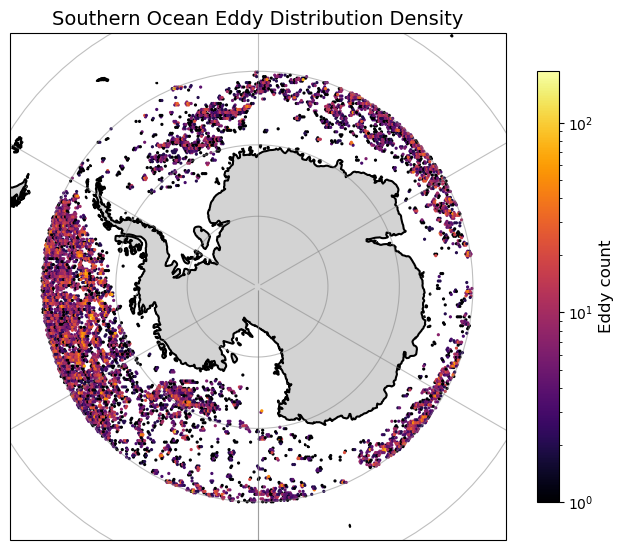

In [11]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

ax.set_extent([0,360, -90, -55], crs=ccrs.PlateCarree())

gl = ax.gridlines(
    draw_labels=False,
    linewidth=0.8,
    color="grey",
    alpha=0.5,
    linestyle="-"
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}


hb = ax.hexbin(
    x_all, y_all,
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj
)

ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.coastlines(linewidth=1.5)

cb = plt.colorbar(hb, ax=ax, shrink=0.7)
cb.set_label("Eddy count", fontsize = 12)

ax.set_title("Southern Ocean Eddy Distribution Density", fontsize = 14)
plt.savefig("eddy_q75e20_distribution_density.pdf")
plt.show()


#### Subset eddies AC/C

In [13]:
lats_ac = edso1_clt_ac_q75_e20["latitude"].values.ravel()
lons_ac = edso1_clt_ac_q75_e20["longitude"].values.ravel()

lats_c = edso1_clt_c_q75_e20["latitude"].values.ravel()
lons_c = edso1_clt_c_q75_e20["longitude"].values.ravel()

#remove missing values
mask_ac = np.isfinite(lats_ac) & np.isfinite(lons_ac)
lats_ac = lats_ac[mask_ac]
lons_ac = lons_ac[mask_ac]

mask_c = np.isfinite(lats_c) & np.isfinite(lons_c)
lats_c = lats_c[mask_c]
lons_c = lons_c[mask_c]

In [14]:
proj = ccrs.SouthPolarStereo()
data_crs = ccrs.PlateCarree()

In [15]:
# Convert lon/lat to projection coordinates
xy_ac = proj.transform_points(data_crs, lons_ac, lats_ac)
x_ac = xy_ac[:, 0]
y_ac = xy_ac[:, 1]

xy_c = proj.transform_points(data_crs, lons_c, lats_c)
x_c = xy_c[:, 0]
y_c = xy_c[:, 1]

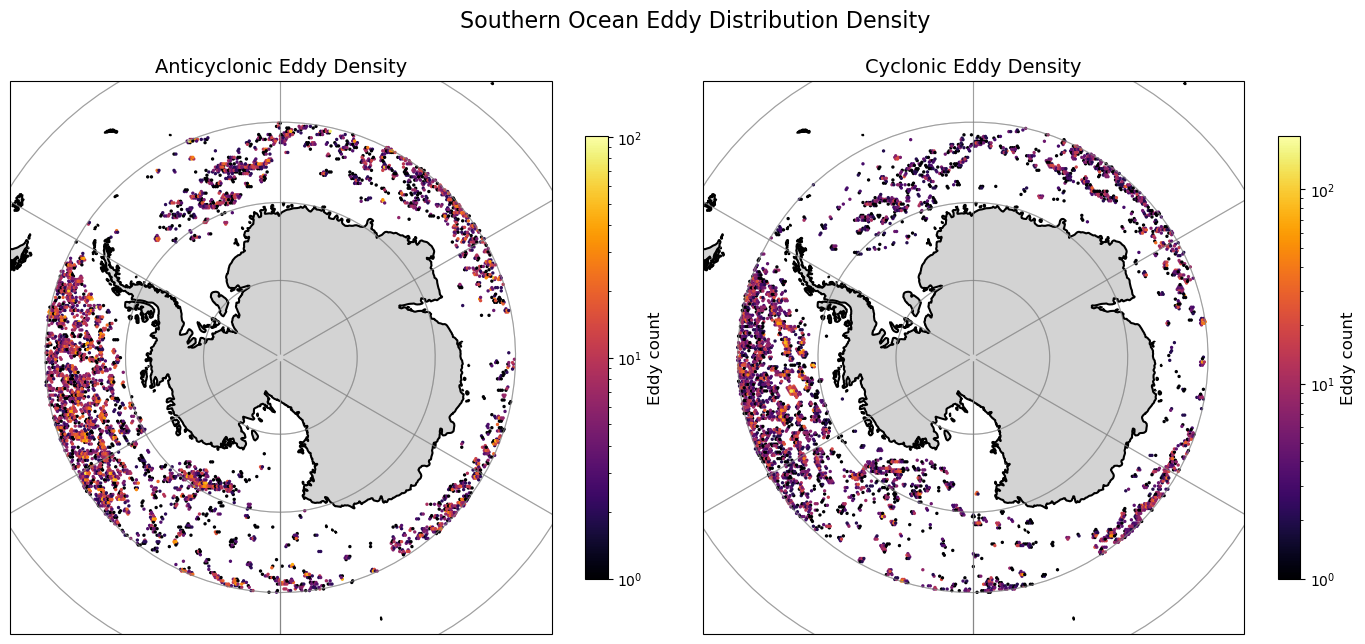

In [16]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 7),
    subplot_kw={"projection": proj}
)
ax1 = axes[0]
ax2 = axes[1]

# --- First subplot: Antcyclonic eddies ---
ax1 = axes[0]
ax1.set_extent([0,360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb1 = ax1.hexbin(
    x_ac, y_ac,                 # AC eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj
)

ax1.add_feature(cfeature.LAND, facecolor="lightgrey")
ax1.coastlines(linewidth=1.5)
cb1 = plt.colorbar(hb1, ax=ax1, shrink=0.7)
cb1.set_label("Eddy count", fontsize = 12)
ax1.set_title("Anticyclonic Eddy Density", fontsize = 14)

# --- Second subplot: Cyclonic eddies ---
ax2 = axes[1]
ax2.set_extent([0,360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb2 = ax2.hexbin(
    x_c, y_c,                   # Cyclonic eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj
)

ax2.add_feature(cfeature.LAND, facecolor="lightgrey")
ax2.coastlines(linewidth=1.5)
cb2 = plt.colorbar(hb2, ax=ax2, shrink=0.7)
cb2.set_label("Eddy count", fontsize = 12)
ax2.set_title("Cyclonic Eddy Density", fontsize = 14)

fig.suptitle("Southern Ocean Eddy Distribution Density", fontsize=16, y=0.97)

plt.tight_layout()
plt.savefig("eddy_distribution_density.pdf")
plt.show()


In [75]:
lats_jul = edso2_clt_jul["latitude"].values.ravel()
lons_jul = edso2_clt_jul["longitude"].values.ravel()

lats_jan = edso2_clt_jan["latitude"].values.ravel()
lons_jan = edso2_clt_jan["longitude"].values.ravel()

#remove missing values
mask_jul = np.isfinite(lats_jul) & np.isfinite(lons_jul)
lats_jul = lats_jul[mask_jul]
lons_jul = lons_jul[mask_jul]

mask_jan = np.isfinite(lats_jan) & np.isfinite(lons_jan)
lats_jan = lats_jan[mask_jan]
lons_jan = lons_jan[mask_jan]

In [76]:
proj = ccrs.SouthPolarStereo()
data_crs = ccrs.PlateCarree()

In [77]:
# Convert lon/lat to projection coordinates
xy_jul = proj.transform_points(data_crs, lons_jul, lats_jul)
x_jul = xy_jul[:, 0]
y_jul = xy_jul[:, 1]

xy_jan = proj_c.transform_points(data_crs, lons_jan, lats_jan)
x_jan = xy_jan[:, 0]
y_jan = xy_jan[:, 1]

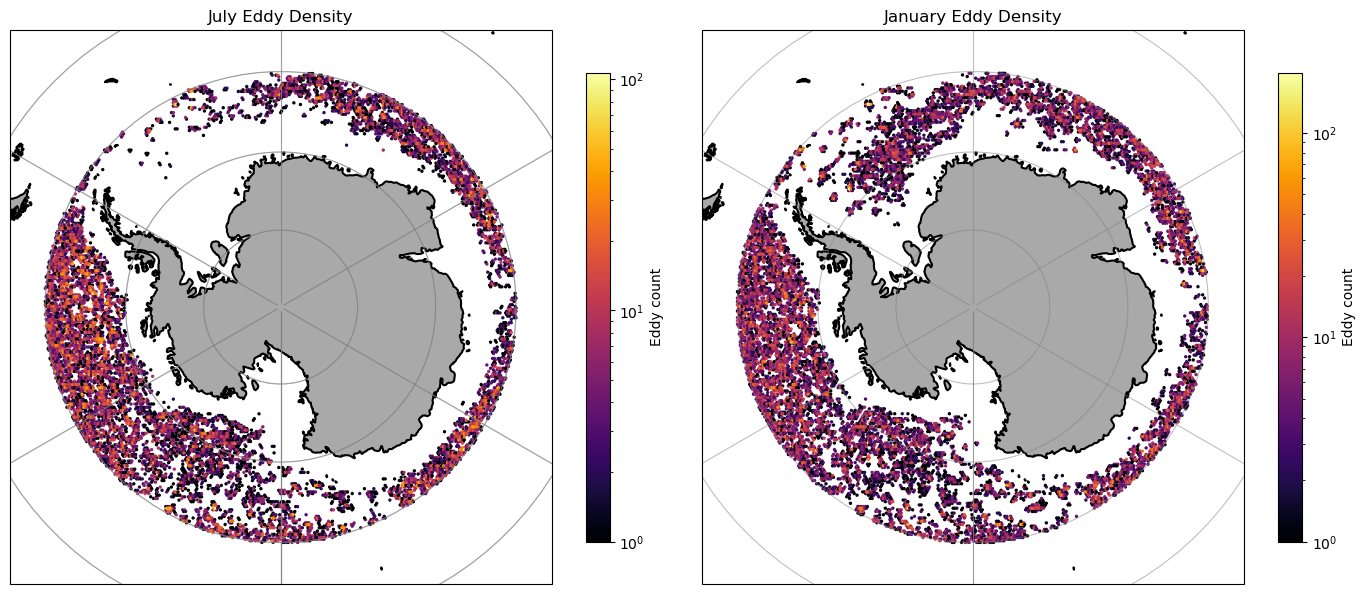

In [81]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 7),
    subplot_kw={"projection": proj}
)

# --- First subplot: July eddies ---
ax1 = axes[0]
ax1.set_extent([0,360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb1 = ax1.hexbin(
    x_jul, y_jul,                 # AC eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj
)

ax1.add_feature(cfeature.LAND, facecolor="darkgrey")
ax1.coastlines(linewidth=1.5)
cb1 = plt.colorbar(hb1, ax=ax1, shrink=0.7)
cb1.set_label("Eddy count")
ax1.set_title("July Eddy Density")

# --- Second subplot: January eddies ---
ax2 = axes[1]
ax2.set_extent([0,360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb2 = ax2.hexbin(
    x_jan, y_jan,                   # Cyclonic eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj
)

ax2.add_feature(cfeature.LAND, facecolor="darkgrey")
ax2.coastlines(linewidth=1.5)
cb2 = plt.colorbar(hb2, ax=ax2, shrink=0.7)
cb2.set_label("Eddy count")
ax2.set_title("January Eddy Density")

plt.tight_layout()
plt.show()


In [24]:
lats_ac = edso_2R_ac["latitude"].values.ravel()
lons_ac = edso_2R_ac["longitude"].values.ravel()

lats_c = edso_2R_c["latitude"].values.ravel()
lons_c = edso_2R_c["longitude"].values.ravel()


In [25]:
#remove missing values
mask_ac = np.isfinite(lats_ac) & np.isfinite(lons_ac)
lats_ac = lats_ac[mask_ac]
lons_ac = lons_ac[mask_ac]

mask_c = np.isfinite(lats_c) & np.isfinite(lons_c)
lats_c = lats_c[mask_c]
lons_c = lons_c[mask_c]

In [26]:
#define project
proj_ac = ccrs.SouthPolarStereo()
data_crs_ac = ccrs.PlateCarree()

proj_c = ccrs.SouthPolarStereo()
data_crs_c = ccrs.PlateCarree()

In [27]:
# Convert lon/lat to projection coordinates
xy_ac = proj_ac.transform_points(data_crs_ac, lons_ac, lats_ac)
x_ac = xy_ac[:, 0]
y_ac = xy_ac[:, 1]

xy_c = proj_c.transform_points(data_crs_c, lons_c, lats_c)
x_c = xy_c[:, 0]
y_c = xy_c[:, 1]

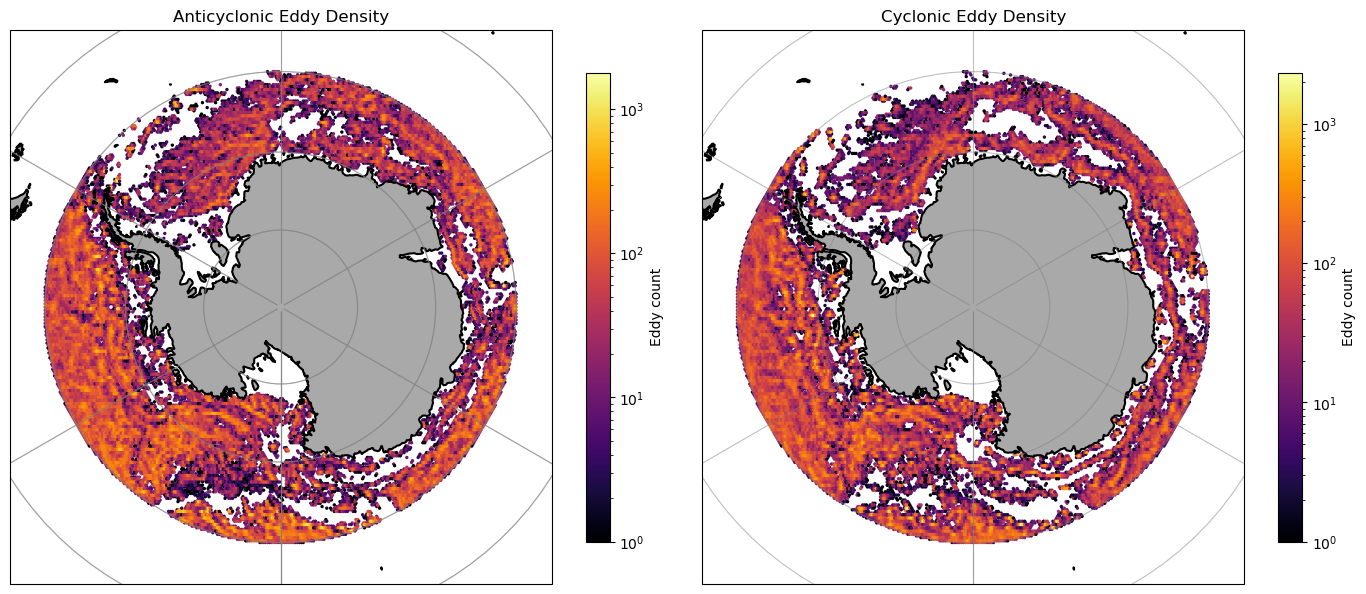

In [28]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 7),
    subplot_kw={"projection": proj_c}
)

# --- First subplot: AC eddies ---
ax1 = axes[0]
ax1.set_extent([0, 360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb1 = ax1.hexbin(
    x_ac, y_ac,                 # AC eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj_c
)

ax1.add_feature(cfeature.LAND, facecolor="darkgrey")
ax1.coastlines(linewidth=1.5)
cb1 = plt.colorbar(hb1, ax=ax1, shrink=0.7)
cb1.set_label("Eddy count")
ax1.set_title("Anticyclonic Eddy Density")

# --- Second subplot: C eddies ---
ax2 = axes[1]
ax2.set_extent([0, 360, -90, -55], crs=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="grey",
        alpha=0.5,
        linestyle="-"
    )
    gl.top_labels = False
    gl.right_labels = False


hb2 = ax2.hexbin(
    x_c, y_c,                   # Cyclonic eddy coordinates
    gridsize=250,
    mincnt=1,
    norm=LogNorm(),
    cmap="inferno",
    transform=proj_c
)

ax2.add_feature(cfeature.LAND, facecolor="darkgrey")
ax2.coastlines(linewidth=1.5)
cb2 = plt.colorbar(hb2, ax=ax2, shrink=0.7)
cb2.set_label("Eddy count")
ax2.set_title("Cyclonic Eddy Density")

plt.tight_layout()
plt.show()

